In [1]:
import zipfile
import os

zip_path = "data.zip"        # path to zip file
extract_path = "data"        # folder where it will unzip

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped files:", os.listdir(extract_path))


Unzipped files: ['Data']


In [2]:
!pip install pillow pillow-heif


   ---------------------------------------- 0.0/5.4 MB ? eta -:--:--
   -------------------------------------- - 5.2/5.4 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------- 5.4/5.4 MB 30.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 72.0 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 10.4.0
    Uninstalling pillow-10.4.0:
      Successfully uninstalled pillow-10.4.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.1.0 which is incompatible.


In [1]:
import os
import shutil
from PIL import Image
import pillow_heif

# Enable HEIC support
pillow_heif.register_heif_opener()

BASE_DIR = os.getcwd()

input_dir  = os.path.join(BASE_DIR, "data", "Data")
output_dir = os.path.join(BASE_DIR, "data_converted")

os.makedirs(output_dir, exist_ok=True)

# Supported image extensions
IMAGE_EXTS = {".heic", ".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

for root, _, files in os.walk(input_dir):
    for file in files:
        ext = os.path.splitext(file)[1].lower()

        if ext not in IMAGE_EXTS:
            continue

        src = os.path.join(root, file)

        # Preserve directory structure
        rel_path = os.path.relpath(root, input_dir)
        dst_dir = os.path.join(output_dir, rel_path)
        os.makedirs(dst_dir, exist_ok=True)

        # Case 1: HEIC → JPG
        if ext == ".heic":
            img = Image.open(src).convert("RGB")
            dst = os.path.join(
                dst_dir,
                os.path.splitext(file)[0] + ".jpg"
            )
            img.save(dst, "JPEG", quality=95)

        # Case 2: Other image types → copy as-is
        else:
            dst = os.path.join(dst_dir, file)
            shutil.copy2(src, dst)
print("HEIC converted + other images copied successfully")


KeyboardInterrupt: 

In [1]:
from ultralytics import YOLO
import os

# 1. Load the model (Use 'yolov8n.pt' to start fresh or your 'best.pt' to continue)
# generally better to start fresh if changing hyperparameters significantly
model = YOLO("yolov8n.pt")  

# 2. Train with improved Hyperparameters for Top-Down Maps
results = model.train(
    data="data.yaml",   # Make sure this points to your yaml file
    epochs=100,         # INCREASED: 10 is too low. 100 allows convergence.
    patience=20,        # Stop early if no improvement for 20 epochs
    imgsz=640,          # 1024 is okay, but 640 is standard and faster. 
                        # If your notes are small, stick to 1024.
    batch=8,
    device=0,
    
    # --- AUGMENTATION FOR MAPS ---
    degrees=15.0,       # Rotate images +/- 15 degrees (helps if paper is crooked)
    fliplr=0.5,         # Flip Left-Right (Standard)
    flipud=0.5,         # CRITICAL: Flip Up-Down (Standard YOLO is 0.0)
    scale=0.5,          # Scale image size (helps detect notes at different distances)
    mosaic=1.0,         # Mixes 4 images (helps with small dataset)
    
    # --- COLOR ACCURACY ---
    # We reduce HSV (Color) jitter slightly so it doesn't confuse 
    # Yellow notes with light Green or faded Pink notes.
    hsv_h=0.015,        # Hue shift (keep small)
    hsv_s=0.4,          # Saturation shift (reduced from 0.7)
    hsv_v=0.4,          # Value (brightness) shift
    
    name="town_planning_run" # Name of the run folder
)

Ultralytics 8.4.7  Python-3.12.7 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=town_planning_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plot

RuntimeError: Dataset 'data.yaml' error  'data.yaml' does not exist

In [2]:
from ultralytics import YOLO
import os

# 1. Load the model (Use 'yolov8n.pt' to start fresh or your 'best.pt' to continue)
# generally better to start fresh if changing hyperparameters significantly
model = YOLO("yolov8n.pt")  

# 2. Train with improved Hyperparameters for Top-Down Maps
results = model.train(
    data="data_bead.yaml",   # Make sure this points to your yaml file
    epochs=100,         # INCREASED: 10 is too low. 100 allows convergence.
    patience=20,        # Stop early if no improvement for 20 epochs
    imgsz=640,          # 1024 is okay, but 640 is standard and faster. 
                        # If your notes are small, stick to 1024.
    batch=8,
    device=0,
    
    # --- AUGMENTATION FOR MAPS ---
    degrees=15.0,       # Rotate images +/- 15 degrees (helps if paper is crooked)
    fliplr=0.5,         # Flip Left-Right (Standard)
    flipud=0.5,         # CRITICAL: Flip Up-Down (Standard YOLO is 0.0)
    scale=0.5,          # Scale image size (helps detect notes at different distances)
    mosaic=1.0,         # Mixes 4 images (helps with small dataset)
    
    # --- COLOR ACCURACY ---
    # We reduce HSV (Color) jitter slightly so it doesn't confuse 
    # Yellow notes with light Green or faded Pink notes.
    hsv_h=0.015,        # Hue shift (keep small)
    hsv_s=0.4,          # Saturation shift (reduced from 0.7)
    hsv_v=0.4,          # Value (brightness) shift
    
    name="town_planning_run" # Name of the run folder
)

Ultralytics 8.4.7  Python-3.12.7 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_bead.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=town_planning_run2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0

In [1]:
from PIL import Image
from ultralytics import YOLO

# Load your newly trained model
best_model = YOLO("runs/detect/town_planning_run2/weights/best.pt")

# Path to a test image
test_image = "C:/Users/Jatin/Desktop/Town Planning/data_converted/Bead factory/IMG20260122190100.jpg" # Update this path

# Predict
results = best_model.predict(
    source=test_image,
    conf=0.15,          # LOWERED: Standard is 0.25. 
                        # If you get 0.02 detections, 0.15 allows you to see them.
    save=True,          # Save the image with boxes drawn
    project="runs/detect",
    name="inference_test",
    exist_ok=True
)

# Show result inside notebook
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
    display(im)

FileNotFoundError: C:/Users/Jatin/Desktop/Town Planning/data_converted/Bead factory/IMG20260122190100.jpg does not exist

✅ Found Label for: Citadel_IMG_7089.jpg


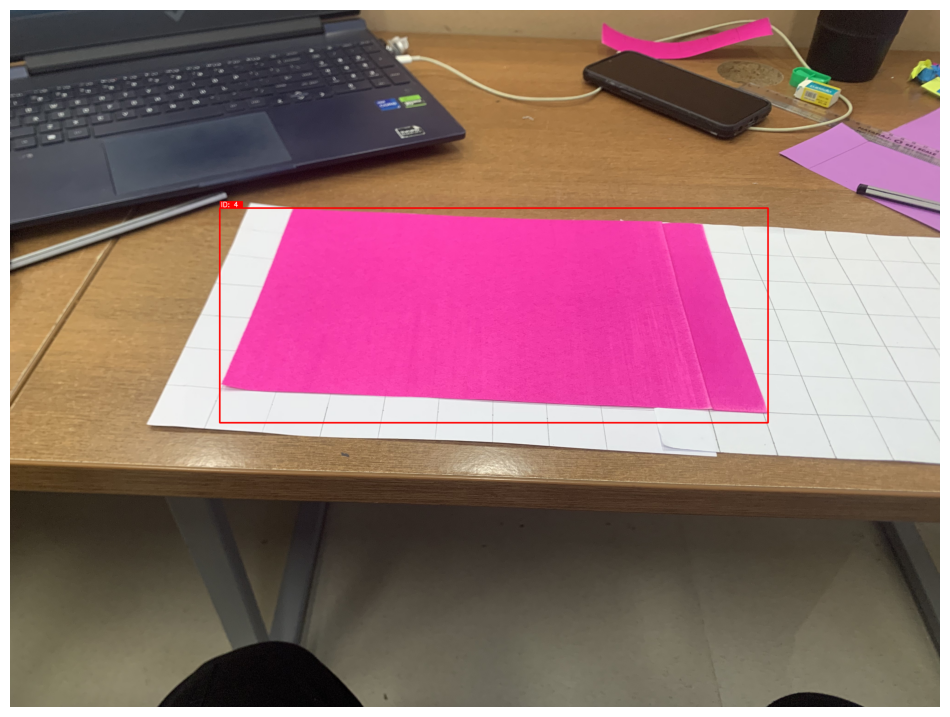

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# --- CORRECTED PATHS ---
base_path = r"C:\Users\Jatin\Desktop\Town Planning\yolo_data2\yolo_data"
# Now points to the 'train' subfolder
images_path = os.path.join(base_path, "images", "train")
labels_path = os.path.join(base_path, "labels", "train")

# 1. Get List of Images
try:
    image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]
except FileNotFoundError:
    print(f"❌ Still can't find path: {images_path}")
    image_files = []

if not image_files:
    print("No images found! Check if the folder name is correct.")
else:
    # 2. Pick Random Image
    random_img = random.choice(image_files)
    img_full_path = os.path.join(images_path, random_img)
    
    # 3. Find matching label
    # This assumes label has exact same name as image (just .txt instead of .jpg)
    label_name = os.path.splitext(random_img)[0] + ".txt"
    label_full_path = os.path.join(labels_path, label_name)

    # 4. Load & Draw
    img = cv2.imread(img_full_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_full_path):
        with open(label_full_path, 'r') as f:
            lines = f.readlines()
            
        print(f"✅ Found Label for: {random_img}")
        for line in lines:
            parts = line.split()
            class_id = int(parts[0])
            
            # YOLO -> Pixel Coordinates
            x_center, y_center, box_w, box_h = map(float, parts[1:])
            x1 = int((x_center - box_w/2) * w)
            y1 = int((y_center - box_h/2) * h)
            x2 = int((x_center + box_w/2) * w)
            y2 = int((y_center + box_h/2) * h)
            
            # Draw Box & ID
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 5)
            # Draw Label Background
            cv2.rectangle(img, (x1, y1-30), (x1+100, y1), (255, 0, 0), -1)
            cv2.putText(img, f"ID: {class_id}", (x1+5, y1 - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    else:
        print(f"⚠️ Image found, but NO label file at: {label_full_path}")

    # 5. Show
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [13]:
from ultralytics import YOLO

# 1. Load a fresh model (recommended when class order changes)
model = YOLO("yolov8n.pt")  

# 2. Train
results = model.train(
    data="data.yaml",  # Points to your new yaml
    epochs=100,                 # Enough time to learn
    imgsz=640,
    batch=8,
    patience=15,
    device=0,
    # --- MAP-SPECIFIC AUGMENTATION ---
    flipud=0.5,     # Critical for top-down maps
    fliplr=0.5,     # Flips left/right
    degrees=15.0,   # Rotates +/- 15 degrees
    mosaic=1.0,     # Helps with small datasets
    
    # --- COLOR TUNING ---
    # Low saturation jitter helps distinguish Yellow Bead Factory from Pink Houses
    hsv_s=0.4,      
    
    project="runs/detect",
    name="town_planning_final_run"
)

Ultralytics 8.4.7  Python-3.12.7 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=town_planning_final_run4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.


image 1/1 C:\Users\Jatin\Downloads\3.jpeg: 640x480 1 warehouse, 1 bead_factory, 8.4ms
Speed: 6.6ms preprocess, 8.4ms inference, 19.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\Jatin\Desktop\Town Planning\runs\detect\runs\inference\test_result


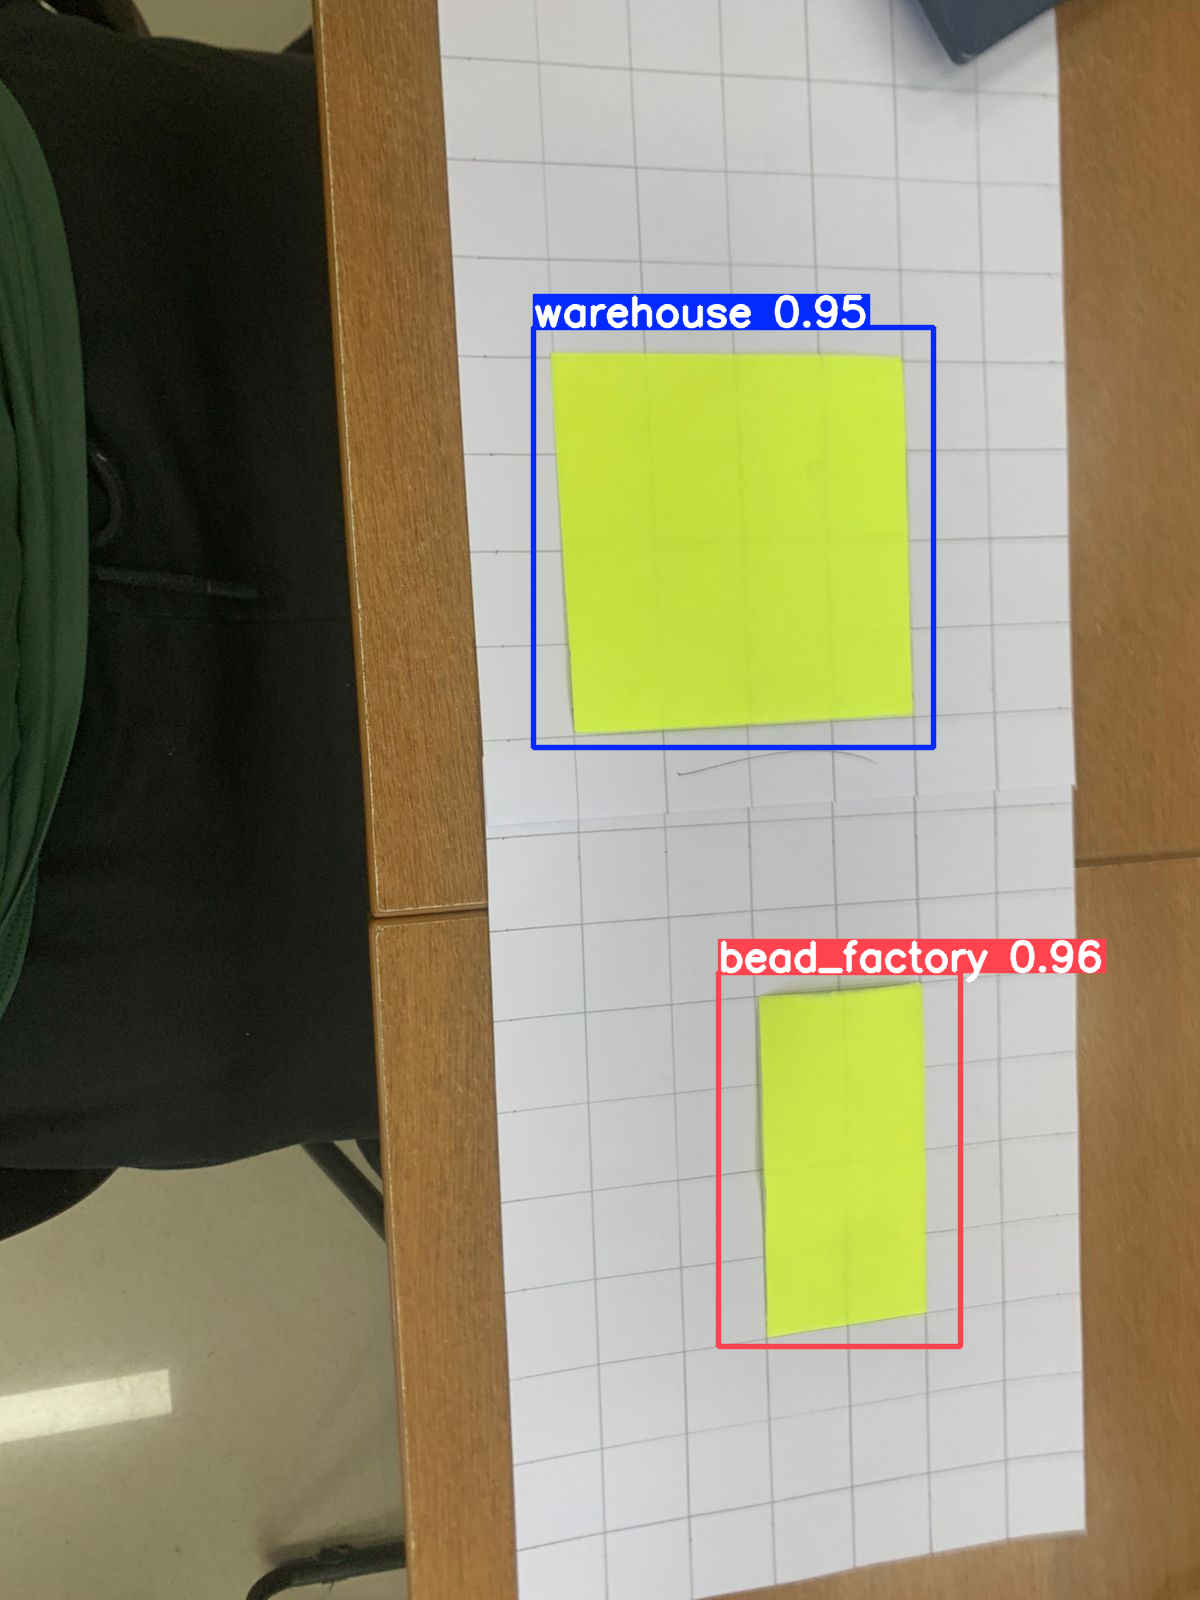

Results saved to: C:\Users\Jatin\Desktop\Town Planning\runs\detect\runs\inference\test_result


In [ ]:
from ultralytics import YOLO
from PIL import Image
import os

# 1. Load the trained model
# Using the path from your logs (check if the double 'runs\detect' is correct on your folder structure)
model_path = r"C:\Users\Jatin\Desktop\Town Planning\runs\detect\runs\detect\town_planning_final_run4\weights\best.pt"

# Safety check to ensure model exists before loading
if not os.path.exists(model_path):
    print(f"path not found: {model_path}")
    print("Check your folders. It might be: runs/detect/town_planning_final_run4/weights/best.pt")
else:
    model = YOLO(model_path)

    # 2. Define the image you want to test
    # Replace this string with the path to your image
    test_image = r"C:\Users\Jatin\Downloads\3.jpeg"
    # 3. Predict
    results = model.predict(
        source=test_image,
        conf=0.25,          # Confidence threshold. Since your model is strong, 0.25 is safe.
        save=True,          # Saves the resulting image to disk
        project="runs/inference", # Where to save the output
        name="test_result",
        exist_ok=True
    )

    # 4. Show the result inside the notebook
    for r in results:
        im_array = r.plot()  # r.plot() returns a BGR numpy array (OpenCV format)
        im = Image.fromarray(im_array[..., ::-1])  # Convert BGR to RGB for correct colors
        display(im)
        
    print(f"Results saved to: {results[0].save_dir}")

In [5]:
import cv2
import math
import itertools
from ultralytics import YOLO

# 1. SETUP
# ---------------------------------------------------------
model_path = r"C:\Users\Jatin\Desktop\Town Planning\runs\detect\runs\detect\town_planning_final_run4\weights\best.pt"
image_path = r"C:\Users\Jatin\Downloads\aaab.jpeg"

# CALIBRATION: Replace 10.0 with your real calibration (pixels per cm)
PIXELS_PER_CM = 20
# ---------------------------------------------------------

# 2. LOAD & PREDICT
model = YOLO(model_path)
results = model.predict(source=image_path, conf=0.25)[0]
img = cv2.imread(image_path)

# 3. EXTRACT ALL OBJECTS
detected_objects = []

for i, box in enumerate(results.boxes):
    cls_id = int(box.cls[0])
    cls_name = model.names[cls_id]
    
    # Get coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    
    obj_data = {
        "id": i,
        "name": cls_name,
        "center": (cx, cy)
    }
    detected_objects.append(obj_data)

    # Draw Box & Label
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Label on top of box
    cv2.putText(img, f"{cls_name}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    cv2.circle(img, (cx, cy), 4, (0, 0, 255), -1)

# 4. CALCULATE DISTANCE & DRAW BOLD TEXT
pairs = list(itertools.combinations(detected_objects, 2))

print(f"✅ Found {len(detected_objects)} objects.")
print(f"Drawing {len(pairs)} distance lines...")

for obj_A, obj_B in pairs:
    pt1 = obj_A["center"]
    pt2 = obj_B["center"]
    
    # Math
    distance_px = math.sqrt((pt2[0] - pt1[0])**2 + (pt2[1] - pt1[1])**2)
    distance_cm = distance_px / PIXELS_PER_CM
    
    # Draw Line (Thin Blue Line)
    cv2.line(img, pt1, pt2, (255, 200, 0), 1) 
    
    # Draw Text at Midpoint
    mid_x = (pt1[0] + pt2[0]) // 2
    mid_y = (pt1[1] + pt2[1]) // 2
    
    label = f"{distance_cm:.1f}" 
    
    # --- UPDATED TEXT SETTINGS ---
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6  # Slightly larger
    thickness = 2     # BOLDER (was 1)
    
    # Calculate text size to make the background box fit perfectly
    (w, h), baseline = cv2.getTextSize(label, font, font_scale, thickness)
    
    # Draw White Background Box (so text is readable over the map)
    cv2.rectangle(img, (mid_x, mid_y - h - 5), (mid_x + w, mid_y + 5), (255, 255, 255), -1)
    
    # Draw BOLD Black Text
    cv2.putText(img, label, (mid_x, mid_y), font, font_scale, (0, 0, 0), thickness)

# 5. SHOW RESULT
window_name = "All Distances (Bold)"
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.imshow(window_name, img)
cv2.waitKey(0)
cv2.destroyAllWindows()


image 1/1 C:\Users\Jatin\Downloads\aaab.jpeg: 640x480 1 warehouse, 1 reservoir, 1 loading_platform, 1 dockyard, 1 citadel, 1 big_house, 12.1ms
Speed: 1.9ms preprocess, 12.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)
✅ Found 6 objects.
Drawing 15 distance lines...
